In [2]:
import networkx as nx

def find_mdst(G):
    """
    Finds the Absolute Center and Minimum Diameter Spanning Tree of an unweighted graph.
    """
    # 1. Compute All-Pairs Shortest Paths (APSP)/
    # Using dictionary comprehension for $O(n^2)$ lookup efficiency
    apsp = dict(nx.all_pairs_shortest_path_length(G))

    min_radius = float('inf')
    absolute_center = None
    is_edge_center = False

    # 2. Check all vertices for their eccentricity
    for v in G.nodes():
        eccentricity = max(apsp[v].values())
        if eccentricity < min_radius:
            min_radius = eccentricity
            absolute_center = v
            is_edge_center = False

    # 3. Check all edge midpoints for their eccentricity
    for u, v in G.edges():
        # Distance from an edge midpoint to any node w is min(d(u,w), d(v,w)) + 0.5
        edge_eccentricity = max(min(apsp[u][w], apsp[v][w]) + 0.5 for w in G.nodes())
        if edge_eccentricity < min_radius:
            min_radius = edge_eccentricity
            absolute_center = (u, v)
            is_edge_center = True

    # 4. Construct the Spanning Tree
    if not is_edge_center:
        # If the center is a vertex, a simple BFS tree suffices
        mdst = nx.bfs_tree(G, absolute_center).to_undirected()
    else:
        # If the center is on an edge, we subdivide the edge with a dummy node,
        # run BFS from the dummy node, and then replace the dummy with the original edge.
        u, v = absolute_center
        G_temp = G.copy()
        G_temp.remove_edge(u, v)
        dummy_node = 'TEMP_CENTER'
        G_temp.add_edge(u, dummy_node)
        G_temp.add_edge(v, dummy_node)

        mdst_temp = nx.bfs_tree(G_temp, dummy_node).to_undirected()

        # Clean up the dummy node to restore the original graph structure in the tree
        mdst_temp.remove_node(dummy_node)
        mdst_temp.add_edge(u, v)
        mdst = mdst_temp

    return mdst, absolute_center, min_radius

# --- Example Usage ---
# Generate a random 3-regular graph (which is likely an expander)
n_nodes = 100
G = nx.random_regular_graph(3, n_nodes)

# Ensure it is connected
if nx.is_connected(G):
    tree, center, radius = find_mdst(G)
    print(f"Absolute Center: {center}")
    print(f"Tree Radius from Center: {radius}")

    # The diameter of the resulting tree will be roughly 2 * radius
    tree_diameter = nx.diameter(tree)
    print(f"Resulting MDST Diameter: {tree_diameter}")
else:
    print("Graph is not connected. MDST cannot be formed.")

Absolute Center: (22, 67)
Tree Radius from Center: 6.5
Resulting MDST Diameter: 13


Absolute Center: (0, 19)
Matchings: {2: [(2, 17)], 6: [(6, 13)], 7: [(7, 8)], 10: [(5, 10)], 11: [(11, 16)], 13: [(13, 14)], 14: [(14, 15)], 15: [(15, 16)], 3: [(2, 3)]}


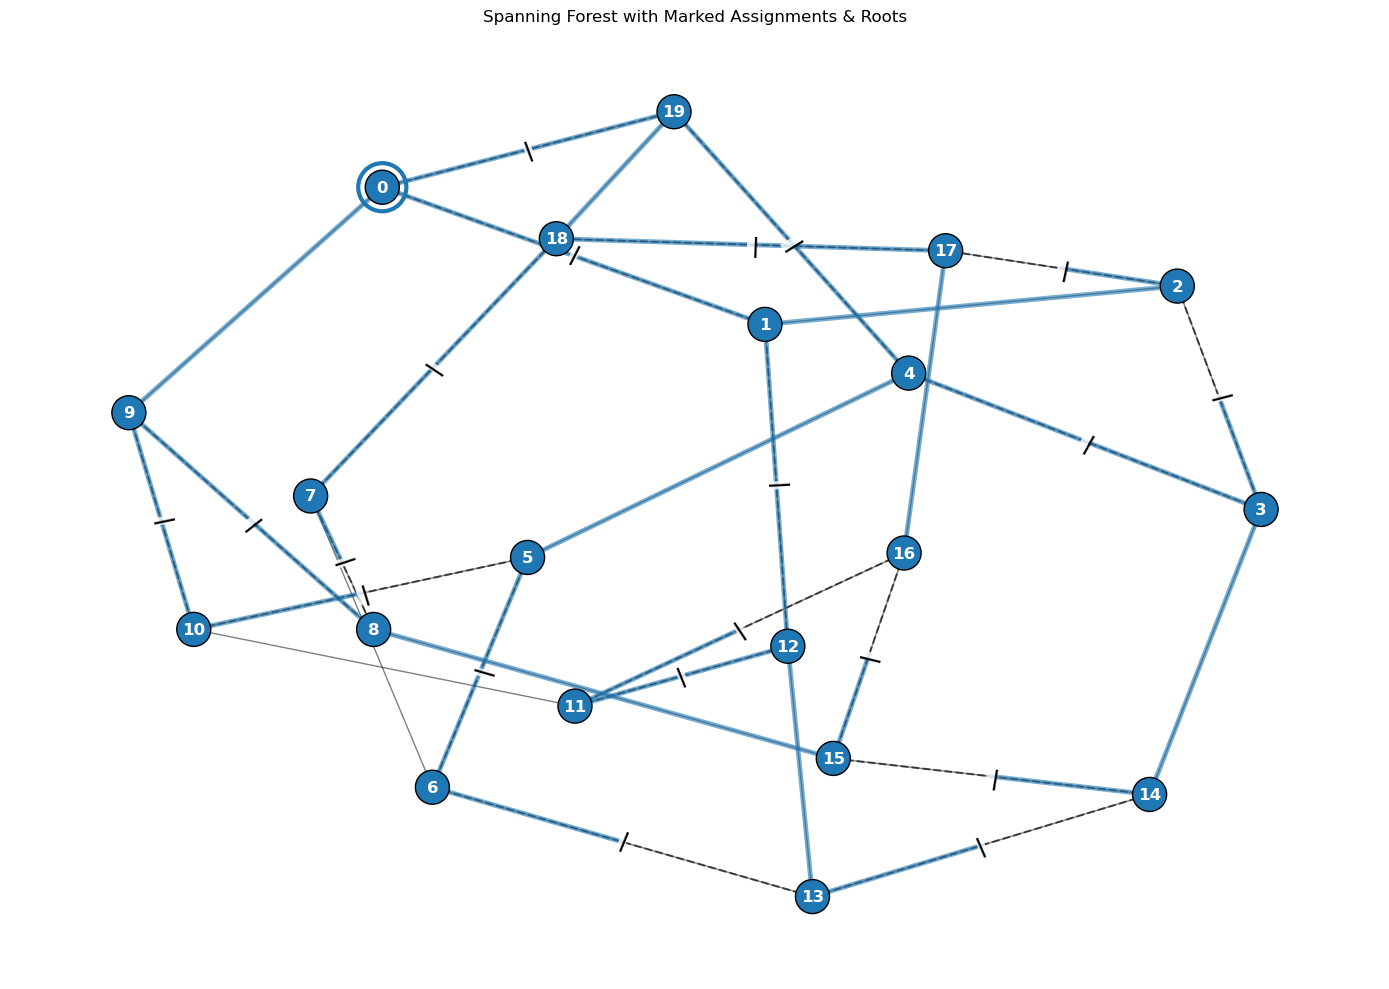

In [5]:
from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import find_min_height_roots, match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet

grf, forest, M, matchings = load_solution_triplet(20, 5, 1)
tree, center, radius = find_mdst(grf)
print(f"Absolute Center: {center}")

matchings = match_forest_leaves_to_marked_edges(grf, tree, M)
print(f"Matchings: {matchings}")
draw_spanning_forest_solution(grf, tree, M, matchings, {0: center[0] if isinstance(center, tuple) else center})


=== Starting Clean Extraction ===
  Estimated Data Qubits: 20
  Flags start at: 20
Init Root 0 (Tree 0) -> Q0
  Node 0 -> Branch 9 (New Q1)
    Link (8, 9) (1st visit): Created Flag 20, CNOT 1->20
    Link (9, 10) (1st visit): Created Flag 21, CNOT 1->21
  Node 0 -> Branch 19 (New Q2)
    Internal Mark (0, 19): Added Q3
    Link (4, 19) (1st visit): Created Flag 22, CNOT 2->22
  Node 19 -> Primary 18 (Inherits Q2)
    Link (7, 18) (1st visit): Created Flag 23, CNOT 2->23
    Link (17, 18) (1st visit): Created Flag 24, CNOT 2->24
  Node 0 -> Primary 1 (Inherits Q0)
    Internal Mark (0, 1): Added Q4
  Node 1 -> Branch 12 (New Q5)
    Internal Mark (1, 12): Added Q6
    Link (11, 12) (1st visit): Created Flag 25, CNOT 5->25
  Node 12 -> Primary 13 (Inherits Q5)
    Match Allocation: Node 13 absorbs (13, 14)
    Link (6, 13) (1st visit): Created Flag 26, CNOT 5->26
    Link (13, 14) (1st visit): Created Flag 27, CNOT 5->27
  Node 1 -> Primary 2 (Inherits Q0)
    Match Allocation: Node 2 (

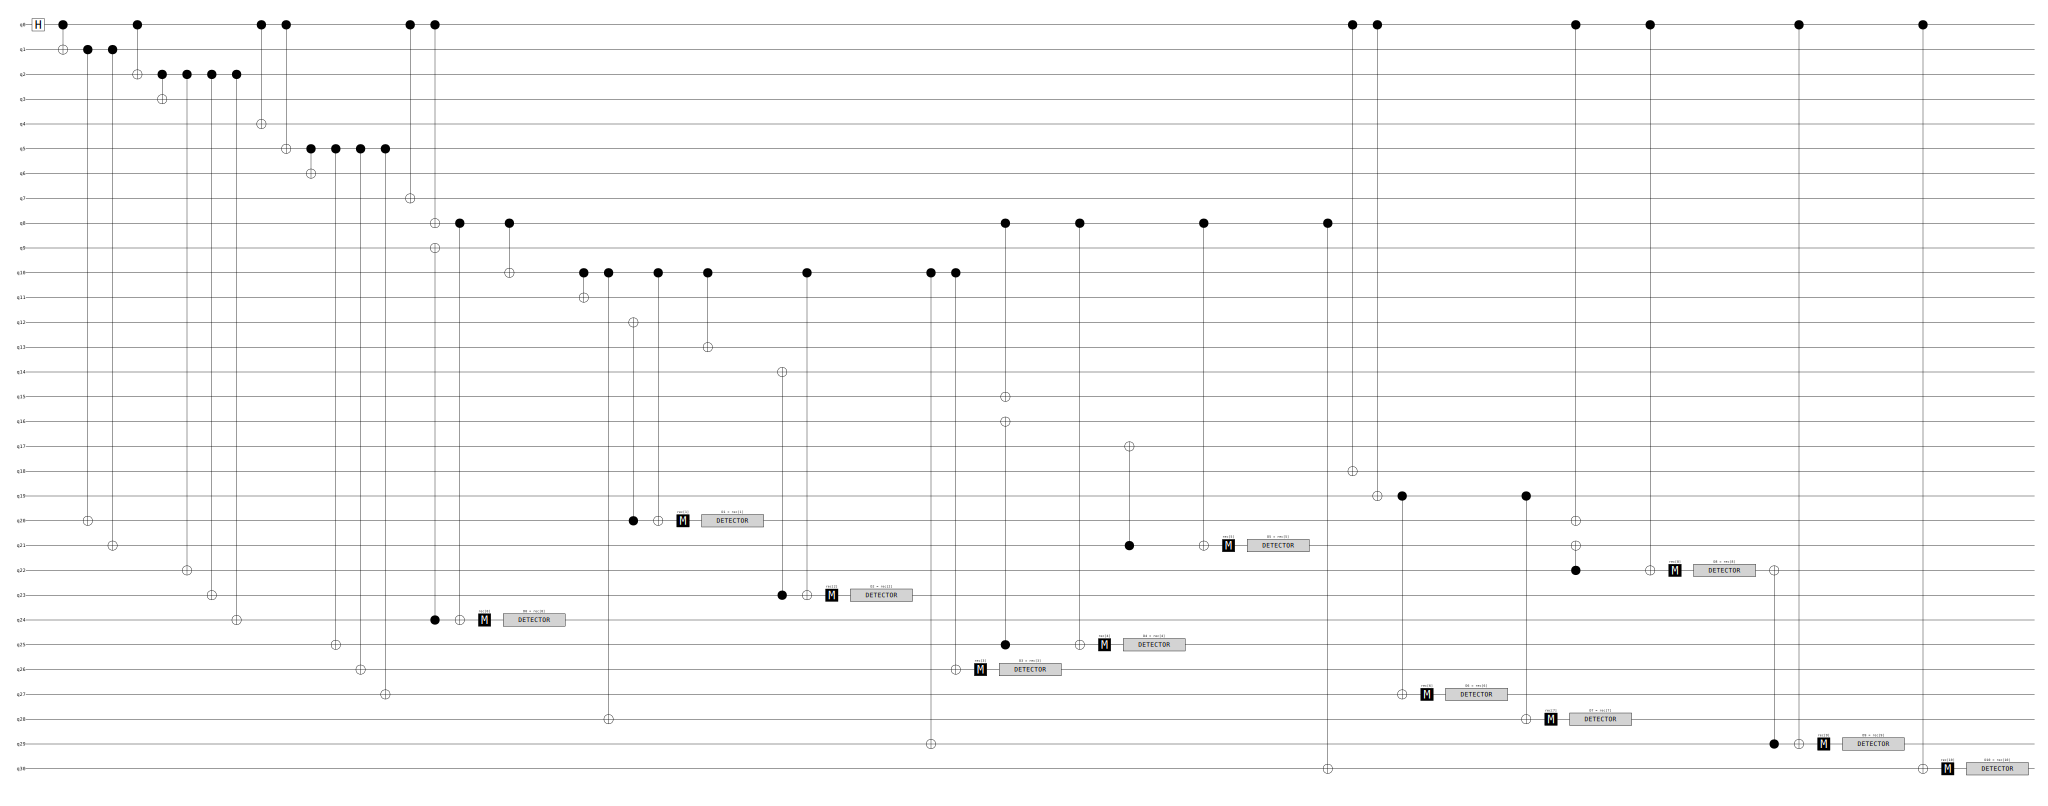

In [6]:
from spidercat.circuit_extraction import extract_circuit_rooted

circ = extract_circuit_rooted(grf, forest, {0: center[0] if isinstance(center, tuple) else center}, M, matchings, verbose=True)
circ.diagram('timeline-svg')

In [ ]:
So m